<a href="https://colab.research.google.com/github/riyarani6180/LLM_Projects/blob/daily_classes/29_may.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

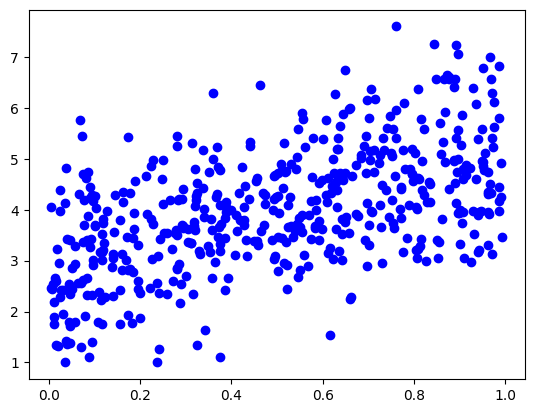

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
m=2
c=3
np.random.seed(42)
x=np.random.rand(500)
y=m*x+c+np.random.randn(500)
plt.plot(x,y,'bo')
plt.show()

In [ ]:
import matplotlib.pyplot as plt
m=2
c=3
np.random.seed(42)
x=np.random.rand(500)
y=m*x+c+np.random.randn(500)



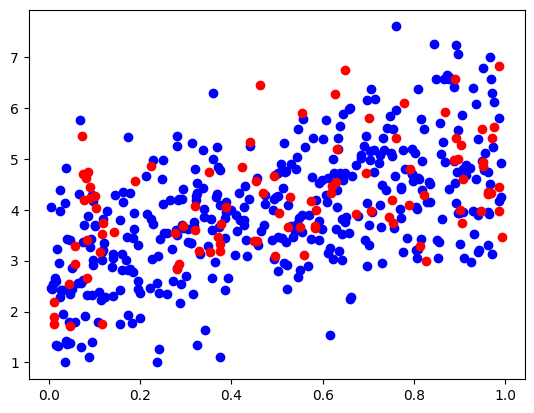

In [ ]:
split_ratio=0.8
split_index=int(split_ratio*len(x))
x_train,x_test=x[:split_index],x[split_index:]
y_train,y_test=y[:split_index],y[split_index:]
plt.plot(x_train,y_train,'bo')
plt.plot(x_test,y_test,'ro')
plt.show()

In [ ]:
split_ratio=0.8
split_index=int(split_ratio*len(x))
x_train,x_test=x[:split_index],x[split_index:]
y_train,y_test=y[:split_index],y[split_index:]
weights=np.random.randn(2)
learning_rate=0.01
epochs=1000
for epoch in range(epochs):
  y_pred=weights[0]+weights[1]*x_train
  error=y_pred-y_train
  gradient_intercept=np.mean(error)
  gradient_slope=np.mean(error*x_train)
  weights[0]-=learning_rate*gradient_intercept
  weights[1]-=learning_rate*gradient_slope


In [ ]:
y_pred_test=weights[0]+weights[1]*x_test
mse=np.mean((y_pred_test-y_test)**2)
print('mean squared error:',mse)

mean squared error: 0.8984391631586993


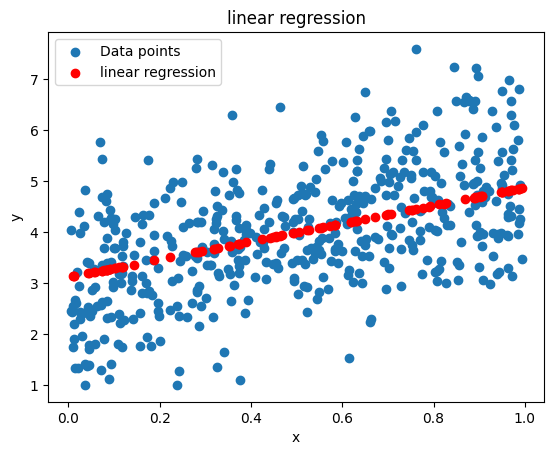

In [ ]:
plt.scatter(x,y,label='Data points')
plt.scatter(x_test,y_pred_test,color='red',label='linear regression')
plt.xlabel('x')
plt.ylabel('y')
plt.title('linear regression')
plt.legend()
plt.show()

In [ ]:
import torch

In [ ]:
torch.__version__

'2.11.0+cpu'

In [ ]:
x=torch.tensor([[1,2,3],[4,5,6]])
y=torch.tensor([[7,8,9],[10,11,12]])
sum=x+y
print(sum)
print(sum.device)

tensor([[ 8, 10, 12],
        [14, 16, 18]])
cpu


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
np.random.seed(42)
x=np.random.rand(100,1)*10
y=2*x+3+np.random.randn(100,1)

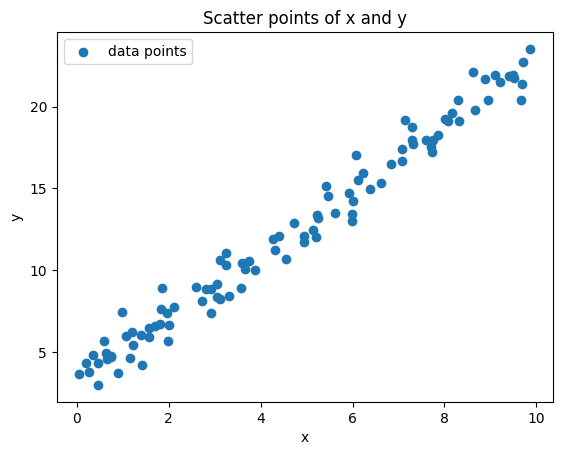

In [ ]:
plt.scatter(x,y,label='data points')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Scatter points of x and y')
plt.legend()
plt.show()

In [ ]:
x_tensor=torch.tensor(x,dtype=torch.float32)
y_tensor=torch.tensor(y,dtype=torch.float32)
def linear_regression(input_size,output_size):
  return nn.Linear(input_size,output_size)
input_size=1
output_size=1
model=linear_regression(input_size,output_size)

In [ ]:
criterian =nn.MSELoss()
optimizer=optim.SGD(model.parameters(),lr=0.01)

In [ ]:
num_epochs=1000
for epoch in range(num_epochs):
  y_pred=model(x_tensor)
  loss=criterian(y_pred,y_tensor)
  optimizer.zero_grad()
  loss.backward()
  optimizer.step()
  if(epoch +1) % 100 ==0:
    print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.4f}')

Epoch [100/1000], Loss: 1.8569
Epoch [200/1000], Loss: 1.1519
Epoch [300/1000], Loss: 0.9201
Epoch [400/1000], Loss: 0.8439
Epoch [500/1000], Loss: 0.8189
Epoch [600/1000], Loss: 0.8106
Epoch [700/1000], Loss: 0.8079
Epoch [800/1000], Loss: 0.8070
Epoch [900/1000], Loss: 0.8067
Epoch [1000/1000], Loss: 0.8066


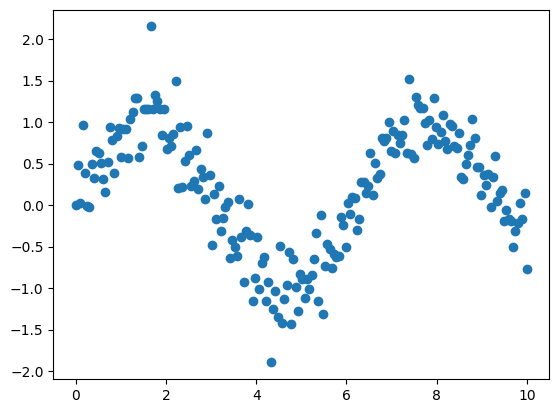

In [ ]:
import numpy as np
num_points=200
x_range=np.linspace(0,10,num_points)
noise=np.random.normal(0,0.3,num_points)
y=np.sin(x_range)+noise
plt.scatter(x_range,y)

In [ ]:
model=nn.Sequential(
    nn.Linear(1,50),
    nn.Tanh(),
    nn.Linear (50,1)
)


In [ ]:
x_data = torch.tensor(x_range, dtype=torch.float32).unsqueeze(1)
y_data = torch.tensor(y, dtype=torch.float32).unsqueeze(1)

criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)


for epoch in range(num_epochs):

  y_pred = model(x_data)
  loss = criterion(y_pred, y_data)

  # Backward and optimize
  optimizer.zero_grad()
  loss.backward()
  optimizer.step()

  # Print progress
  if (epoch + 1) % 100 == 0:
    print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.4f}')

Epoch [100/1000], Loss: 0.2276
Epoch [200/1000], Loss: 0.1825
Epoch [300/1000], Loss: 0.1509
Epoch [400/1000], Loss: 0.1024
Epoch [500/1000], Loss: 0.0860
Epoch [600/1000], Loss: 0.0782
Epoch [700/1000], Loss: 0.0771
Epoch [800/1000], Loss: 0.0846
Epoch [900/1000], Loss: 0.0761
Epoch [1000/1000], Loss: 0.0759


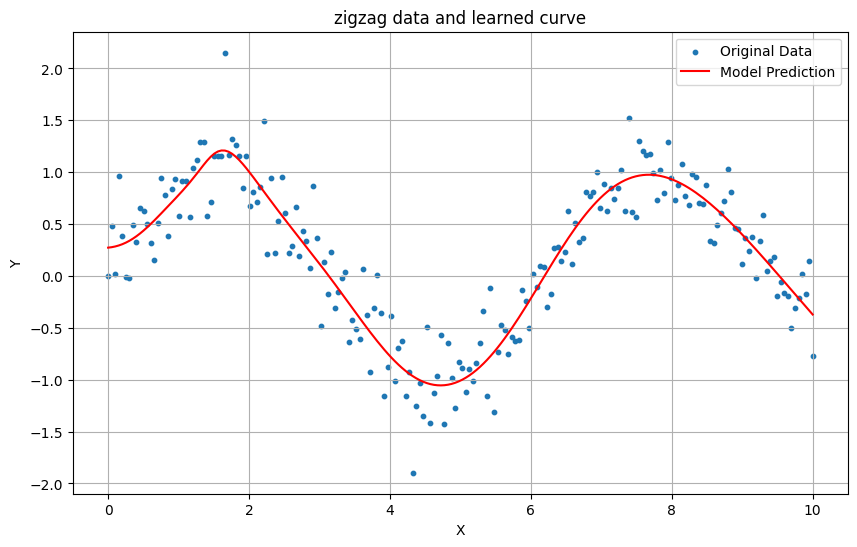

In [ ]:
model.eval()
with torch.no_grad():
  y_pred_plot = model(x_data)

plt.figure(figsize=(10, 6))
plt.scatter(x_data.numpy(), y_data.numpy(), label='Original Data', s=10)
plt.plot(x_data.numpy(), y_pred_plot.numpy(), color='red', label='Model Prediction')
plt.xlabel('X')
plt.ylabel('Y')
plt.title('zigzag data and learned curve')
plt.legend()
plt.grid(True)
plt.show()